In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchvision.utils import save_image
from PIL import Image
from torchvision.io import read_image
from sklearn.model_selection import train_test_split

In [2]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_to_index = {}
        self.index_to_label = {}

        for idx, label in enumerate(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, label)
            if os.path.isdir(class_dir):
                self.label_to_index[label] = idx  
                self.index_to_label[idx] = label  
                for img_name in os.listdir(class_dir):
                    img_path = os.path.join(class_dir, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(idx)  # Store the index instead of the label name

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if image.mode == 'L':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels[idx])  # Convert label to tensor
        return image, label

    def num_classes(self):
        return len(self.label_to_index)  # Return the number of unique classes

    def get_class_name(self, index):
        return self.index_to_label.get(index, "Unknown")  # Retrieve class name by index

In [3]:
image_dir = 'datasets/cnn_dataset/cnn_dataset' 
transform = transforms.Compose([
    transforms.Resize((28, 28)),  
    transforms.ToTensor(),         
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [4]:
full_dataset = CustomDataset(root_dir=image_dir, transform=transform)
num_classes = full_dataset.num_classes()
print(f'Number of classes: {num_classes}')

Number of classes: 36


In [5]:
# Print the mapping from index to label
for index in range(num_classes):
    class_name = full_dataset.get_class_name(index)
    print(f'Index {index} corresponds to class: {class_name}')

Index 0 corresponds to class: 0
Index 1 corresponds to class: 1
Index 2 corresponds to class: 2
Index 3 corresponds to class: 3
Index 4 corresponds to class: 4
Index 5 corresponds to class: 5
Index 6 corresponds to class: 6
Index 7 corresponds to class: 7
Index 8 corresponds to class: 8
Index 9 corresponds to class: 9
Index 10 corresponds to class: A
Index 11 corresponds to class: B
Index 12 corresponds to class: C
Index 13 corresponds to class: D
Index 14 corresponds to class: E
Index 15 corresponds to class: F
Index 16 corresponds to class: G
Index 17 corresponds to class: H
Index 18 corresponds to class: I
Index 19 corresponds to class: J
Index 20 corresponds to class: K
Index 21 corresponds to class: L
Index 22 corresponds to class: M
Index 23 corresponds to class: N
Index 24 corresponds to class: O
Index 25 corresponds to class: P
Index 26 corresponds to class: Q
Index 27 corresponds to class: R
Index 28 corresponds to class: S
Index 29 corresponds to class: T
Index 30 corresponds

In [132]:
mean = 0.0
std = 0.0
total_images = 0

data_loader = DataLoader(full_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
for images, _ in data_loader:
    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)  
    mean += images.mean(2).sum(0)  
    std += images.std(2).sum(0)    
    total_images += batch_size

mean /= total_images
std /= total_images

print(f'Mean: {mean}')
print(f'Standard Deviation: {std}')

Mean: tensor([-0.6484, -0.6484, -0.6484])
Standard Deviation: tensor([0.6541, 0.6541, 0.6541])


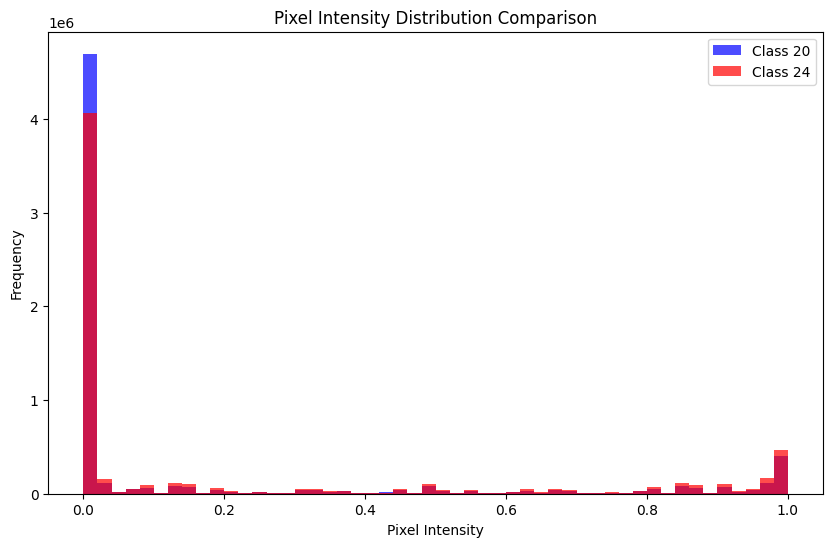

In [136]:
import random

transform_1 = transforms.Compose([
    transforms.Resize((28, 28)),  
    transforms.ToTensor()])
viz_dataset = CustomDataset(root_dir=image_dir, transform=transform_1)

class_1 = random.choice(range(num_classes))  
class_2 = random.choice([i for i in range(num_classes) if i != class_1]) 

class_1_pixels = [img.view(-1).cpu().numpy() for img, lbl in viz_dataset if lbl == class_1]
class_2_pixels = [img.view(-1).cpu().numpy() for img, lbl in viz_dataset if lbl == class_2]

# Flatten the pixel arrays
class_1_pixels = np.concatenate(class_1_pixels, axis=0)
class_2_pixels = np.concatenate(class_2_pixels, axis=0)

# Plot histograms for pixel intensities
plt.figure(figsize=(10, 6))
plt.hist(class_1_pixels, bins=50, color='blue', alpha=0.7, label=f'Class {class_1}')
plt.hist(class_2_pixels, bins=50, color='red', alpha=0.7, label=f'Class {class_2}')
plt.title("Pixel Intensity Distribution Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

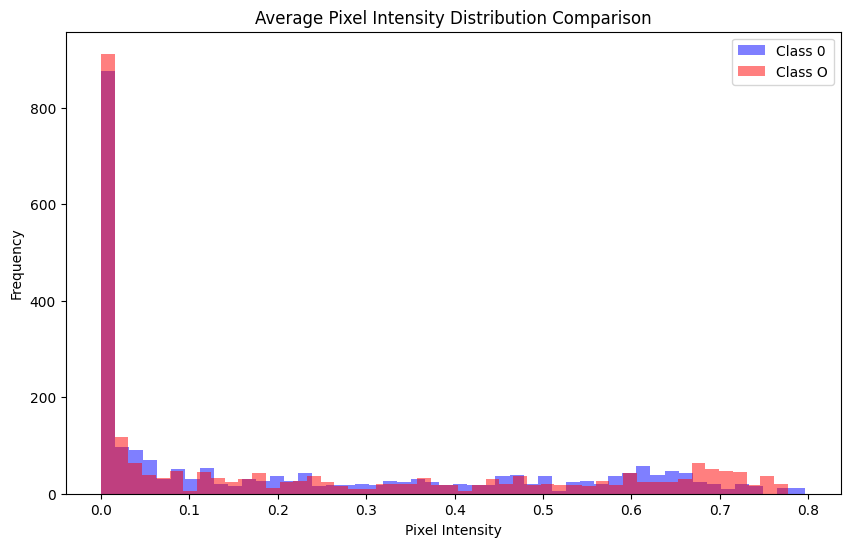

In [15]:
class_1 = 0
class_2 = 24

class_1_images = []
class_2_images = []

for i, label in enumerate(viz_dataset.labels):
    if label == class_1:
        img, _ = viz_dataset[i]
        class_1_images.append(img.view(-1).cpu().numpy())
    elif label == class_2:
        img, _ = viz_dataset[i]
        class_2_images.append(img.view(-1).cpu().numpy())

class_1_avg = np.mean(class_1_images, axis=0)
class_2_avg = np.mean(class_2_images, axis=0)

plt.figure(figsize=(10, 6))
plt.hist(class_1_avg, bins=50, alpha=0.5, label=f'Class {viz_dataset.get_class_name(class_1)}', color='blue')
plt.hist(class_2_avg, bins=50, alpha=0.5, label=f'Class {viz_dataset.get_class_name(class_2)}', color='red')
plt.title('Average Pixel Intensity Distribution Comparison')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [33]:
data = pd.DataFrame({
    'image_paths': full_dataset.image_paths,
    'labels': full_dataset.labels
})

# Train, val, test split
train_df, temp_df = train_test_split(data, test_size=0.4, stratify=data['labels'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)

train_dataset = CustomDataset(root_dir=image_dir, transform=transform)
train_dataset.image_paths = train_df['image_paths'].tolist()
train_dataset.labels = train_df['labels'].tolist()

val_dataset = CustomDataset(root_dir=image_dir, transform=transform)
val_dataset.image_paths = val_df['image_paths'].tolist()
val_dataset.labels = val_df['labels'].tolist()

test_dataset = CustomDataset(root_dir=image_dir, transform=transform)
test_dataset.image_paths = test_df['image_paths'].tolist()
test_dataset.labels = test_df['labels'].tolist()

In [7]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

print(f'Number of training batches: {len(train_loader)}')
print(f'Number of validation batches: {len(val_loader)}')
print(f'Number of test batches: {len(test_loader)}')

Number of training batches: 473
Number of validation batches: 158
Number of test batches: 158


In [8]:
train_distribution = train_df['labels'].value_counts()

val_distribution = val_df['labels'].value_counts()

test_distribution = test_df['labels'].value_counts()

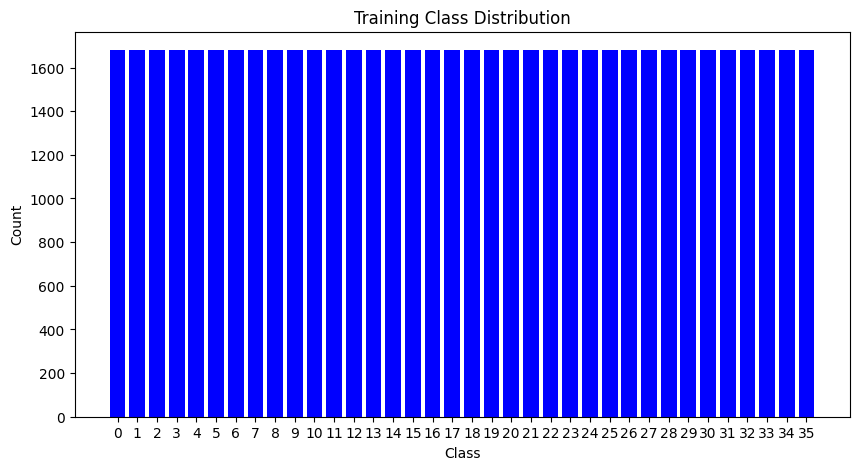

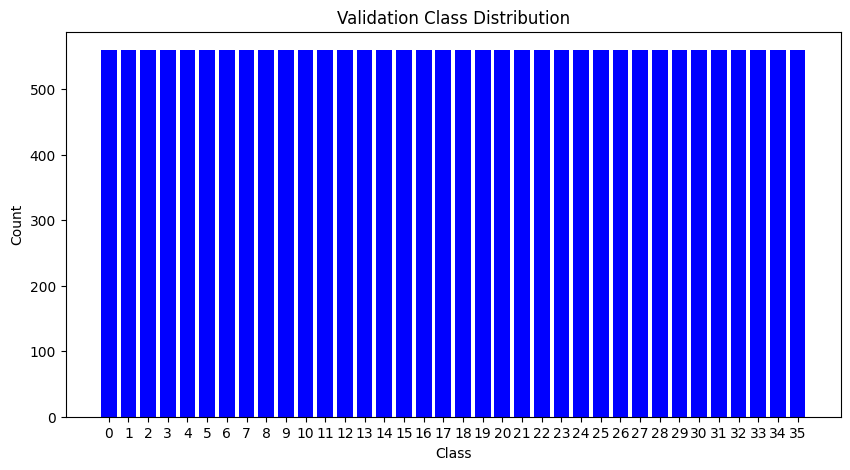

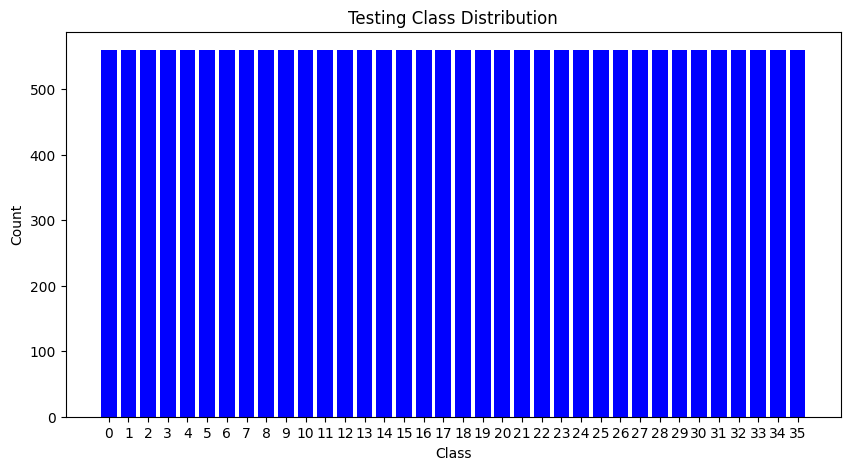

In [9]:
def plot_class_distribution(distribution, title):
    distribution.sort_index(inplace=True)  
    plt.figure(figsize=(10, 5))
    plt.bar(distribution.index, distribution.values, color='blue')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.xticks(distribution.index) 
    plt.show()

# Plot distributions
plot_class_distribution(train_distribution, 'Training Class Distribution')
plot_class_distribution(val_distribution, 'Validation Class Distribution')
plot_class_distribution(test_distribution, 'Testing Class Distribution')

In [10]:
# Sanity check for input sizes
for images, labels in train_loader:
    print(f'Images batch shape: {images.shape}')  
    print(f'Labels batch shape: {labels.shape}')  
    break 

for images, labels in val_loader:
    print(f'Images batch shape: {images.shape}') 
    print(f'Labels batch shape: {labels.shape}')  
    break  

for images, labels in test_loader:
    print(f'Images batch shape: {images.shape}')  
    print(f'Labels batch shape: {labels.shape}')  
    break  

Images batch shape: torch.Size([128, 3, 28, 28])
Labels batch shape: torch.Size([128])
Images batch shape: torch.Size([128, 3, 28, 28])
Labels batch shape: torch.Size([128])
Images batch shape: torch.Size([128, 3, 28, 28])
Labels batch shape: torch.Size([128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


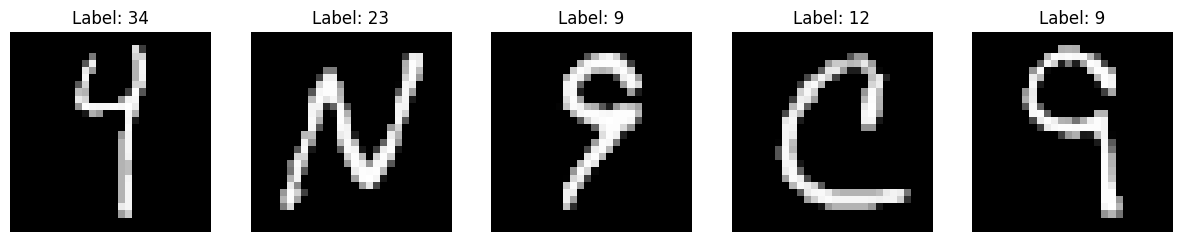

In [11]:
def show_samples(data_loader):
    images, labels = next(iter(data_loader))
    images = images.permute(0, 2, 3, 1)  
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    
    for i in range(5):  
        axes[i].imshow(images[i].cpu().numpy())
        axes[i].set_title(f'Label: {labels[i].item()}')
        axes[i].axis('off')
    
    plt.show()

# Show samples from the training dataset
show_samples(train_loader)

In [12]:
num_batches_to_check = 5
train_unique_labels = set()
for i, (images, labels) in enumerate(val_loader):
    train_unique_labels.update(labels.cpu().numpy())
    if i + 1 >= num_batches_to_check:
        break 

print(f'Unique labels in the sampled training dataset: {train_unique_labels}')
print(f'Number of unique labels in the sampled training dataset: {len(train_unique_labels)}')

Unique labels in the sampled training dataset: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)}
Number of unique labels in the sampled training dataset: 36


In [46]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),      
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)       
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),  
            nn.ReLU(),
            nn.Linear(128, 36)        
        )

    def forward(self, x):
        x = self.conv_layers(x)  
        x = x.flatten(start_dim=1)  
        x = self.fc_layers(x)      
        return x

In [47]:
#!pip install torchinfo
from torchinfo import summary

model = SimpleCNN()
summary(model, input_size=(128, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [128, 36]                 --
├─Sequential: 1-1                        [128, 32, 7, 7]           --
│    └─Conv2d: 2-1                       [128, 16, 28, 28]         448
│    └─ReLU: 2-2                         [128, 16, 28, 28]         --
│    └─MaxPool2d: 2-3                    [128, 16, 14, 14]         --
│    └─Conv2d: 2-4                       [128, 32, 14, 14]         4,640
│    └─ReLU: 2-5                         [128, 32, 14, 14]         --
│    └─MaxPool2d: 2-6                    [128, 32, 7, 7]           --
├─Sequential: 1-2                        [128, 36]                 --
│    └─Linear: 2-7                       [128, 128]                200,832
│    └─ReLU: 2-8                         [128, 128]                --
│    └─Linear: 2-9                       [128, 36]                 4,644
Total params: 210,564
Trainable params: 210,564
Non-trainable params: 0
T

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

cuda


In [16]:
epochs = 8
train_loader = train_loader  
val_loader = val_loader 

In [17]:
import time
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()


for epoch in range(epochs):
    model.train()  
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        images, labels = batch  
        images, labels = images.to(device), labels.to(device)  

        optimizer.zero_grad()  
        outputs = model(images)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    print("Epoch train complete:", epoch)

    # Validation step
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            images, labels = batch  
            images, labels = images.to(device), labels.to(device) 
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

end = time.time()
print(f'Training complete in {end - start:.2f} seconds')

Epoch train complete: 0
Epoch 1/8, Train Loss: 0.890810761907892, Train Accuracy: 73.23412698412699, Validation Loss: 0.4352326323337193, Validation Accuracy: 85.1438492063492
Epoch train complete: 1
Epoch 2/8, Train Loss: 0.36784093797080863, Train Accuracy: 87.12136243386243, Validation Loss: 0.347321261097736, Validation Accuracy: 88.13988095238095
Epoch train complete: 2
Epoch 3/8, Train Loss: 0.3050330175405829, Train Accuracy: 88.96494708994709, Validation Loss: 0.3260351471319983, Validation Accuracy: 88.59623015873017
Epoch train complete: 3
Epoch 4/8, Train Loss: 0.2714507956585471, Train Accuracy: 90.00330687830687, Validation Loss: 0.30275510911700093, Validation Accuracy: 89.33531746031746
Epoch train complete: 4
Epoch 5/8, Train Loss: 0.24573420515839192, Train Accuracy: 90.66964285714286, Validation Loss: 0.28469150871792925, Validation Accuracy: 89.81646825396825
Epoch train complete: 5
Epoch 6/8, Train Loss: 0.22535022992412335, Train Accuracy: 91.37566137566138, Valida

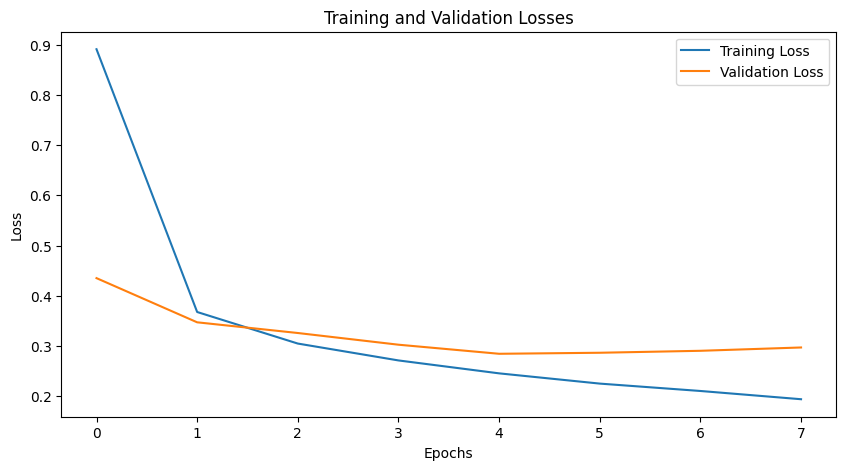

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [19]:
# Set the model to evaluation mode
model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

Test Accuracy: 89.79%
Test Loss: 0.3066587685784207


# Optimzing CNN

## Method 1 - Batch Normalization

In [54]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),    
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)       
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128), 
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 36)        
        )

    def forward(self, x):
        x = self.conv_layers(x)  
        x = x.flatten(start_dim=1)  
        x = self.fc_layers(x)      
        return x

In [55]:
model = SimpleCNN()
summary(model, input_size=(128, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [128, 36]                 --
├─Sequential: 1-1                        [128, 32, 7, 7]           --
│    └─Conv2d: 2-1                       [128, 16, 28, 28]         448
│    └─BatchNorm2d: 2-2                  [128, 16, 28, 28]         32
│    └─ReLU: 2-3                         [128, 16, 28, 28]         --
│    └─MaxPool2d: 2-4                    [128, 16, 14, 14]         --
│    └─Conv2d: 2-5                       [128, 32, 14, 14]         4,640
│    └─BatchNorm2d: 2-6                  [128, 32, 14, 14]         64
│    └─ReLU: 2-7                         [128, 32, 14, 14]         --
│    └─MaxPool2d: 2-8                    [128, 32, 7, 7]           --
├─Sequential: 1-2                        [128, 36]                 --
│    └─Linear: 2-9                       [128, 128]                200,832
│    └─BatchNorm1d: 2-10                 [128, 128]                256
│    

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 8
train_loader = train_loader  
val_loader = val_loader 

In [57]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()  
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        images, labels = batch  
        images, labels = images.to(device), labels.to(device)  

        optimizer.zero_grad()  
        outputs = model(images)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    print("Epoch train complete:", epoch)

    # Validation step
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            images, labels = batch  
            images, labels = images.to(device), labels.to(device) 
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

end = time.time()
print(f'Training complete in {end - start:.2f} seconds')

Epoch train complete: 0
Epoch 1/8, Train Loss: 0.6709926286850116, Train Accuracy: 83.41269841269842, Validation Loss: 0.3358179684492606, Validation Accuracy: 89.03769841269842
Epoch train complete: 1
Epoch 2/8, Train Loss: 0.2874704229686779, Train Accuracy: 89.95535714285714, Validation Loss: 0.2857704586526261, Validation Accuracy: 90.05952380952381
Epoch train complete: 2
Epoch 3/8, Train Loss: 0.23488428998132085, Train Accuracy: 91.32440476190476, Validation Loss: 0.26689095851741257, Validation Accuracy: 90.39682539682539
Epoch train complete: 3
Epoch 4/8, Train Loss: 0.20306154126281717, Train Accuracy: 92.27513227513228, Validation Loss: 0.25883052271755436, Validation Accuracy: 90.58035714285714
Epoch train complete: 4
Epoch 5/8, Train Loss: 0.18122386456670014, Train Accuracy: 92.99272486772487, Validation Loss: 0.25761807714647883, Validation Accuracy: 90.66468253968254
Epoch train complete: 5
Epoch 6/8, Train Loss: 0.16392157489855244, Train Accuracy: 93.53174603174604, V

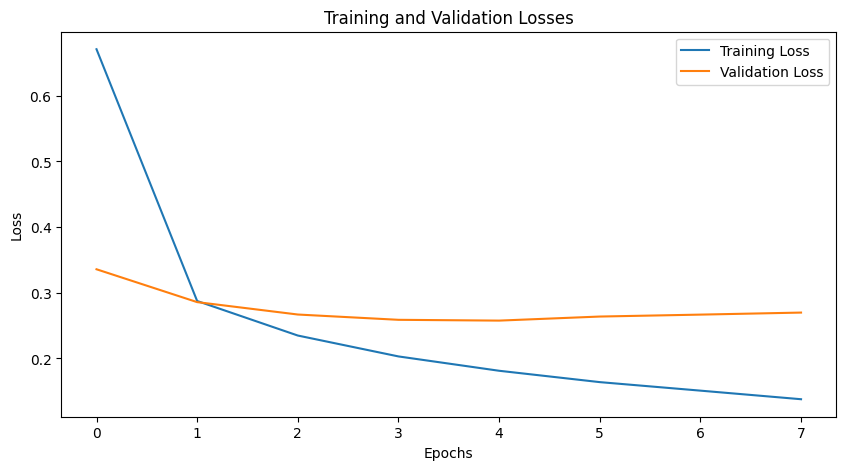

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [59]:
model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

Test Accuracy: 90.46%
Test Loss: 0.2765410041224353


In [60]:
torch.save(model.state_dict(), 'CNN_BN_model.pth')

## Method 2 - Learning Rate Scheduler

In [36]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),      
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)       
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),  
            nn.ReLU(),
            nn.Linear(128, 36)        
        )

    def forward(self, x):
        x = self.conv_layers(x)  
        x = x.flatten(start_dim=1)  
        x = self.fc_layers(x)      
        return x

model = SimpleCNN()
summary(model, input_size=(128, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [128, 36]                 --
├─Sequential: 1-1                        [128, 32, 7, 7]           --
│    └─Conv2d: 2-1                       [128, 16, 28, 28]         448
│    └─ReLU: 2-2                         [128, 16, 28, 28]         --
│    └─MaxPool2d: 2-3                    [128, 16, 14, 14]         --
│    └─Conv2d: 2-4                       [128, 32, 14, 14]         4,640
│    └─ReLU: 2-5                         [128, 32, 14, 14]         --
│    └─MaxPool2d: 2-6                    [128, 32, 7, 7]           --
├─Sequential: 1-2                        [128, 36]                 --
│    └─Linear: 2-7                       [128, 128]                200,832
│    └─ReLU: 2-8                         [128, 128]                --
│    └─Linear: 2-9                       [128, 36]                 4,644
Total params: 210,564
Trainable params: 210,564
Non-trainable params: 0
T

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 8
train_loader = train_loader  
val_loader = val_loader 

In [38]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()


for epoch in range(epochs):
    model.train()  
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        images, labels = batch  
        images, labels = images.to(device), labels.to(device)  

        optimizer.zero_grad()  
        outputs = model(images)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    print("Epoch train complete:", epoch)

    # Validation step
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            images, labels = batch  
            images, labels = images.to(device), labels.to(device) 
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    
    scheduler.step(avg_val_loss)
    
end = time.time()
print(f'Training complete in {end - start:.2f} seconds')

C:\Users\mitta\anaconda3\envs\ML_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch train complete: 0
Epoch 1/8, Train Loss: 0.8577982067557772, Train Accuracy: 74.21130952380952, Validation Loss: 0.43049769509065, Validation Accuracy: 85.74900793650794
Epoch train complete: 1
Epoch 2/8, Train Loss: 0.371185447934062, Train Accuracy: 86.99239417989418, Validation Loss: 0.35361378111794023, Validation Accuracy: 87.88194444444444
Epoch train complete: 2
Epoch 3/8, Train Loss: 0.30487616845341614, Train Accuracy: 89.01785714285714, Validation Loss: 0.3220990317154534, Validation Accuracy: 88.62599206349206
Epoch train complete: 3
Epoch 4/8, Train Loss: 0.27067372839244175, Train Accuracy: 89.95205026455027, Validation Loss: 0.2920756660213199, Validation Accuracy: 89.75198412698413
Epoch train complete: 4
Epoch 5/8, Train Loss: 0.2473356108206775, Train Accuracy: 90.68617724867725, Validation Loss: 0.2917554276653483, Validation Accuracy: 89.53373015873017
Epoch train complete: 5
Epoch 6/8, Train Loss: 0.22832001109329894, Train Accuracy: 91.35747354497354, Validat

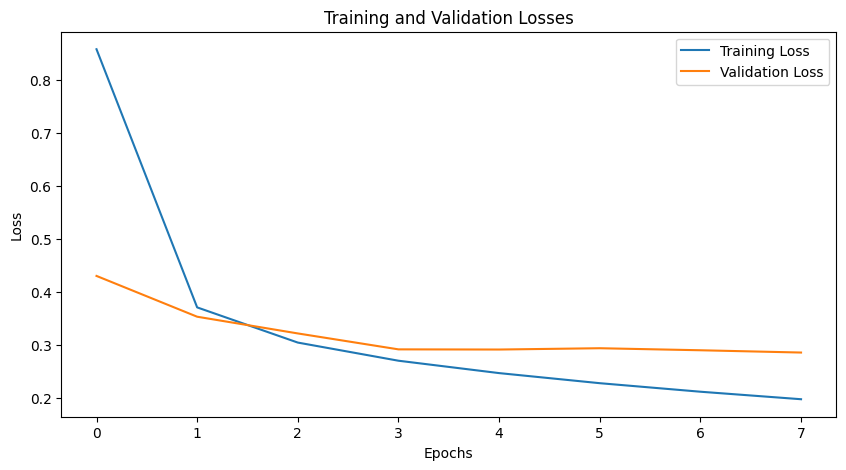

Test Accuracy: 90.00%
Test Loss: 0.29456126039163977


In [39]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

## Method 3 - Early Stopping

In [41]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),      
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)       
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),  
            nn.ReLU(),
            nn.Linear(128, 36)        
        )

    def forward(self, x):
        x = self.conv_layers(x)  
        x = x.flatten(start_dim=1)  
        x = self.fc_layers(x)      
        return x

model = SimpleCNN()
summary(model, input_size=(128, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [128, 36]                 --
├─Sequential: 1-1                        [128, 32, 7, 7]           --
│    └─Conv2d: 2-1                       [128, 16, 28, 28]         448
│    └─ReLU: 2-2                         [128, 16, 28, 28]         --
│    └─MaxPool2d: 2-3                    [128, 16, 14, 14]         --
│    └─Conv2d: 2-4                       [128, 32, 14, 14]         4,640
│    └─ReLU: 2-5                         [128, 32, 14, 14]         --
│    └─MaxPool2d: 2-6                    [128, 32, 7, 7]           --
├─Sequential: 1-2                        [128, 36]                 --
│    └─Linear: 2-7                       [128, 128]                200,832
│    └─ReLU: 2-8                         [128, 128]                --
│    └─Linear: 2-9                       [128, 36]                 4,644
Total params: 210,564
Trainable params: 210,564
Non-trainable params: 0
T

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 8
train_loader = train_loader  
val_loader = val_loader 

In [43]:
import copy

class EarlyStopping:
    def __init__(self, patience=3, delta=0, verbose=False, path='best_model.pth'):

        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path

        self.best_val_loss = float('inf')  
        self.counter = 0  
        self.early_stop = False  
        self.best_model_weights = None  

    def __call__(self, val_loss, model):
        if self.best_val_loss - val_loss > self.delta:
            self.best_val_loss = val_loss 
            self.best_model_weights = copy.deepcopy(model.state_dict()) 
            self.counter = 0 
            if self.verbose:
                print(f"Validation loss improved: {self.best_val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement in validation loss. Counter: {self.counter}/{self.patience}")

        if self.counter >= self.patience:
            self.early_stop = True
            if self.verbose:
                print(f"Early stopping triggered! Best validation loss: {self.best_val_loss:.4f}")
    
    def load_best_model(self, model):
        model.load_state_dict(self.best_model_weights)

In [44]:
early_stopping = EarlyStopping(patience=3, verbose=True)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()


for epoch in range(epochs):
    model.train()  
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        images, labels = batch  
        images, labels = images.to(device), labels.to(device)  

        optimizer.zero_grad()  
        outputs = model(images)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    print("Epoch train complete:", epoch)

    # Validation step
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            images, labels = batch  
            images, labels = images.to(device), labels.to(device) 
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print(f"Training stopped early at epoch {epoch + 1}")
        break

# Load the best model weights from early stopping callback
early_stopping.load_best_model(model)
    
end = time.time()
print(f'Training complete in {end - start:.2f} seconds')

Epoch train complete: 0
Epoch 1/8, Train Loss: 0.8123889208848079, Train Accuracy: 75.13723544973546, Validation Loss: 0.3992132955714117, Validation Accuracy: 86.30952380952381
Validation loss improved: 0.3992
Epoch train complete: 1
Epoch 2/8, Train Loss: 0.3634704044895999, Train Accuracy: 87.19080687830687, Validation Loss: 0.34144473028711125, Validation Accuracy: 87.94146825396825
Validation loss improved: 0.3414
Epoch train complete: 2
Epoch 3/8, Train Loss: 0.30148236226707886, Train Accuracy: 88.93849206349206, Validation Loss: 0.3115055091396163, Validation Accuracy: 89.26587301587301
Validation loss improved: 0.3115
Epoch train complete: 3
Epoch 4/8, Train Loss: 0.26800158229237125, Train Accuracy: 90.1223544973545, Validation Loss: 0.2988334035948862, Validation Accuracy: 89.50396825396825
Validation loss improved: 0.2988
Epoch train complete: 4
Epoch 5/8, Train Loss: 0.23931784696294187, Train Accuracy: 90.95238095238095, Validation Loss: 0.2798335895979706, Validation Acc

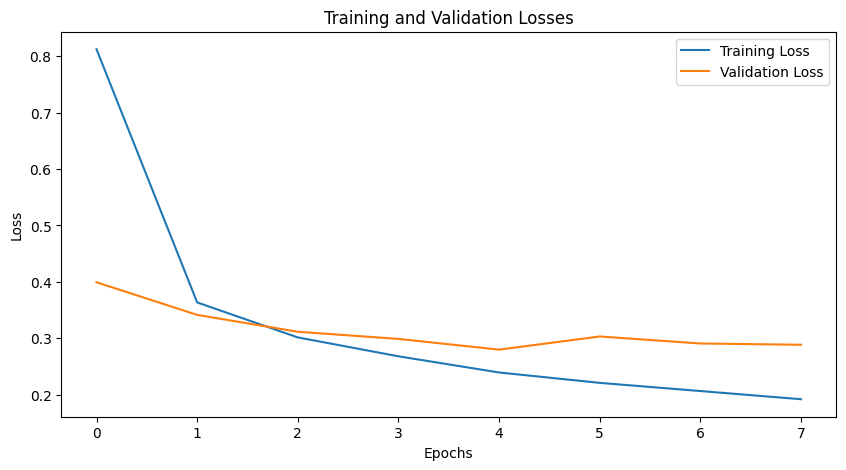

Test Accuracy: 90.09%
Test Loss: 0.28708584078505067


In [45]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

## Loading and Running the best model (best test accuracy) - Option 1: Batch Normalization

In [61]:
model = SimpleCNN()
model.load_state_dict(torch.load('CNN_BN_model.pth'))
model.to(device)

C:\Users\mitta\AppData\Local\Temp\ipykernel_17608\2038711623.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('CNN_BN_model.pth'))


SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=1568, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=36, bias=True)
  )
)

In [62]:
#Checking test accuracy
model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

Test Accuracy: 90.46%
Test Loss: 0.2765410041224353


In [63]:
test_accuracy = test_accuracy
test_loss = test_loss / len(test_loader)

test_accuracy_list = [test_accuracy] * epochs
test_loss_list = [test_loss] * epochs

print(test_accuracy_list)
print(test_loss_list)

[90.4563492063492, 90.4563492063492, 90.4563492063492, 90.4563492063492, 90.4563492063492, 90.4563492063492, 90.4563492063492, 90.4563492063492]
[0.2765410041224353, 0.2765410041224353, 0.2765410041224353, 0.2765410041224353, 0.2765410041224353, 0.2765410041224353, 0.2765410041224353, 0.2765410041224353]


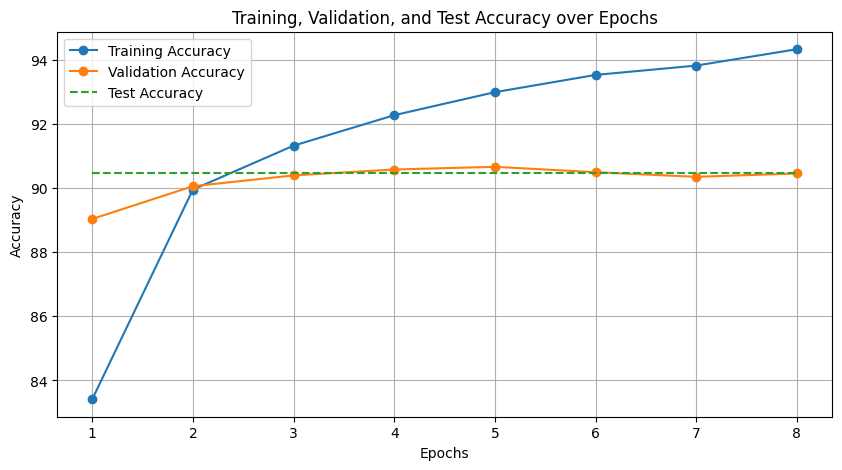

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')

plt.title('Training, Validation, and Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

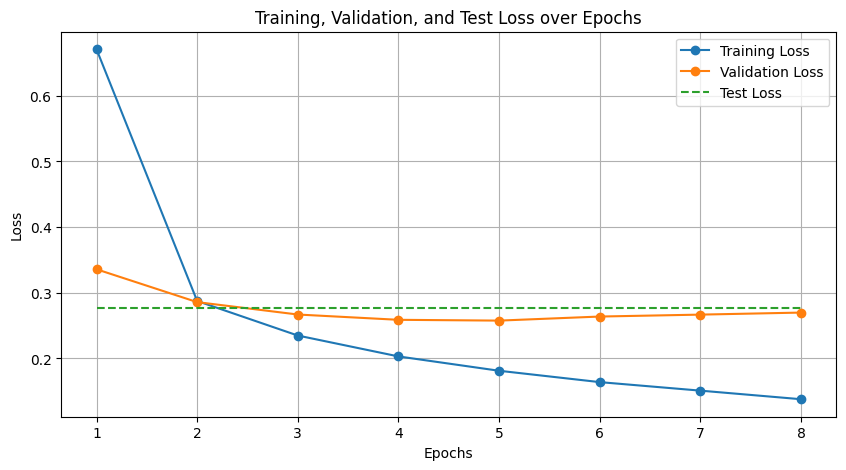

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.plot(range(1, epochs + 1), test_loss_list, label='Test Loss', linestyle='--')

plt.title('Training, Validation, and Test Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

torch.Size([20160, 36])
torch.Size([20160])


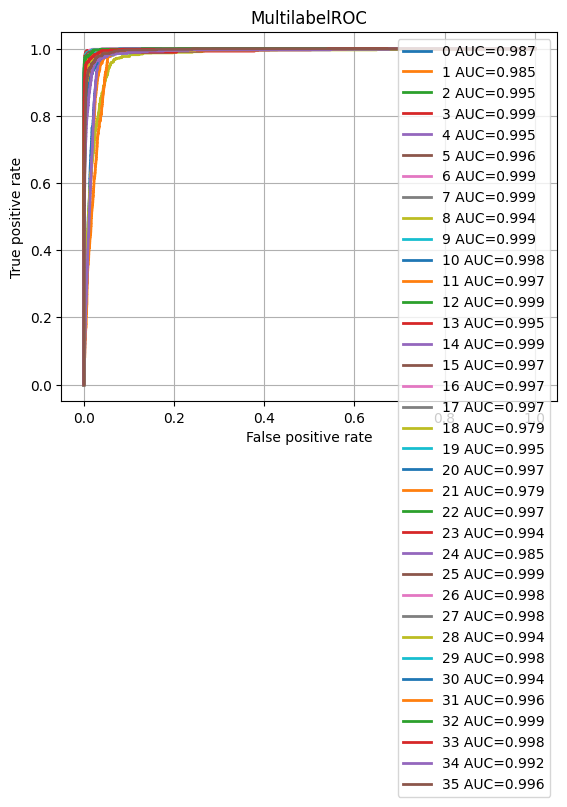

In [131]:
from sklearn.metrics import roc_auc_score
from torchmetrics.classification import MulticlassF1Score


roc = torchmetrics.classification.MultilabelROC(num_labels = 36)

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        y_true.append(labels)
        y_scores.append(outputs)

        #roc.update(predicted, labels)

y_scores = torch.cat(y_scores, dim=0)
y_true = torch.cat(y_true, dim=0)
print(y_scores.shape)
print(y_true.shape)

y_true_one_hot = torch.zeros(y_true.size(0), num_classes, device=y_true.device, dtype=torch.long)
y_true_one_hot.scatter_(1, y_true.unsqueeze(1), 1)

roc.update(y_scores, y_true_one_hot)
fig_, ax_ = roc.plot(score=True)

In [125]:
precision = torchmetrics.classification.MulticlassPrecision(num_classes=36).to(device)
recall = torchmetrics.classification.MulticlassRecall(num_classes=36).to(device)
f1 = torchmetrics.classification.MulticlassF1Score(num_classes=36).to(device)

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs, dim=1)
        y_true.append(labels)
        y_scores.append(y_pred)

        #roc.update(predicted, labels)

y_scores = torch.cat(y_scores, dim=0)
y_true = torch.cat(y_true, dim=0)
print(y_scores.shape)
print(y_true.shape)
print("\n")

precision.update(y_scores, y_true)
recall.update(y_scores, y_true)
f1.update(y_scores, y_true)

precision = precision.compute()
recall = recall.compute()
f1 = f1.compute()

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

torch.Size([20160])
torch.Size([20160])


Precision: 0.9065465927124023
Recall: 0.9045634865760803
F1 Score: 0.9044032692909241


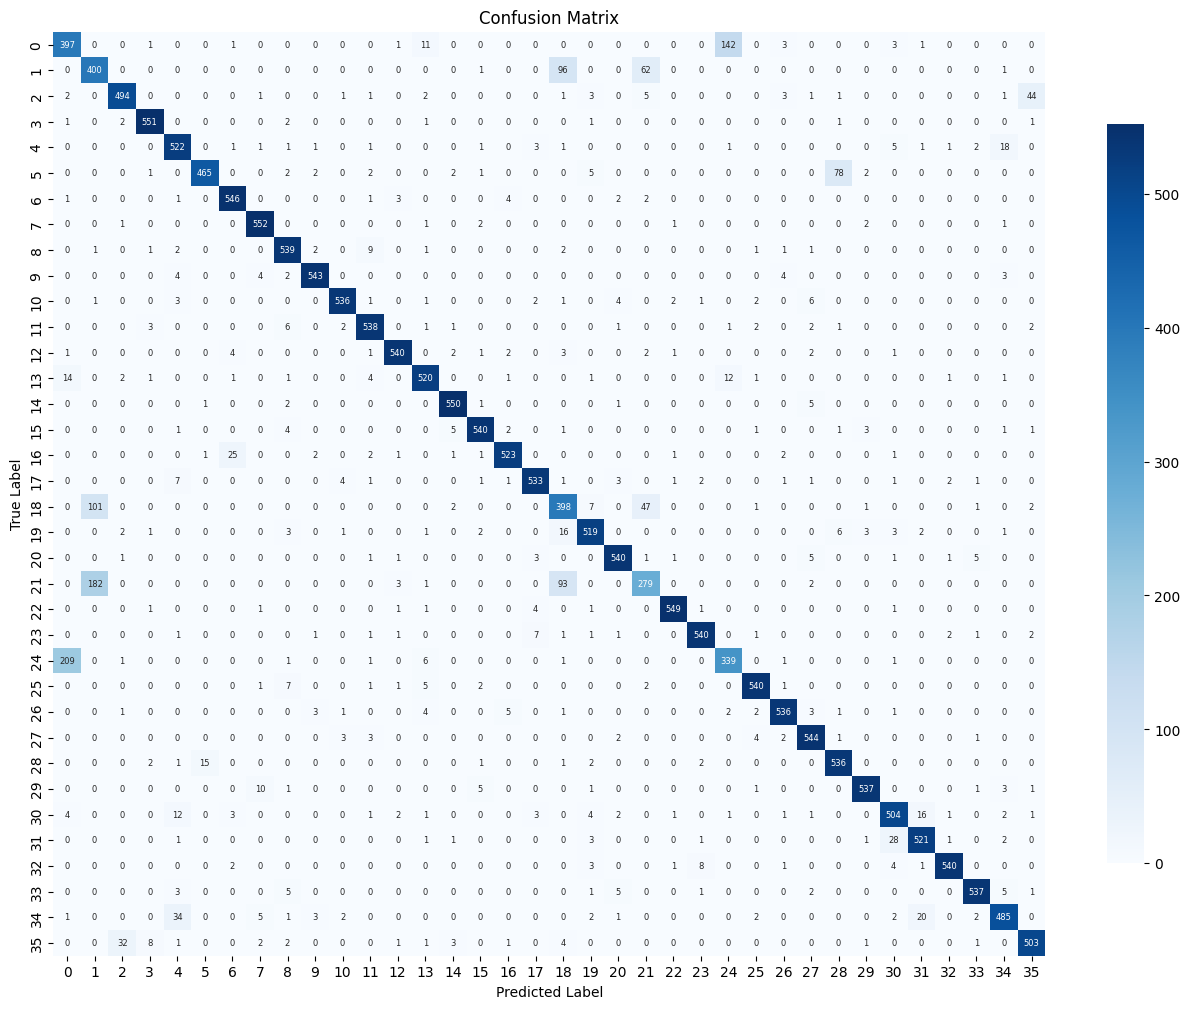

In [130]:
from sklearn.metrics import confusion_matrix

y_true_cpu = y_true.cpu().numpy() 
y_pred_cpu = y_scores.cpu().numpy()  

cm = confusion_matrix(y_true_cpu, y_pred_cpu, labels=np.arange(num_classes))
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes),
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.8})
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# VGG - 13 using PyTorch

In [56]:
image_dir = 'datasets/cnn_dataset/cnn_dataset' 
transform = transforms.Compose([
    transforms.Resize((28, 28)),  
    transforms.ToTensor(),         
    transforms.Normalize((0.1751,), (0.3332,)),
])

In [57]:
full_dataset = CustomDataset(root_dir=image_dir, transform=transform)
num_classes = full_dataset.num_classes()
print(f'Number of classes: {num_classes}')

Number of classes: 36


In [58]:
data = pd.DataFrame({
    'image_paths': full_dataset.image_paths,
    'labels': full_dataset.labels
})

# Train, val, test split
train_df, temp_df = train_test_split(data, test_size=0.4, stratify=data['labels'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)

train_dataset = CustomDataset(root_dir=image_dir, transform=transform)
train_dataset.image_paths = train_df['image_paths'].tolist()
train_dataset.labels = train_df['labels'].tolist()

val_dataset = CustomDataset(root_dir=image_dir, transform=transform)
val_dataset.image_paths = val_df['image_paths'].tolist()
val_dataset.labels = val_df['labels'].tolist()

test_dataset = CustomDataset(root_dir=image_dir, transform=transform)
test_dataset.image_paths = test_df['image_paths'].tolist()
test_dataset.labels = test_df['labels'].tolist()

In [59]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f'Number of training batches: {len(train_loader)}')
print(f'Number of validation batches: {len(val_loader)}')
print(f'Number of test batches: {len(test_loader)}')

Number of training batches: 237
Number of validation batches: 79
Number of test batches: 79


In [60]:
from torchinfo import summary
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class VGG13(nn.Module):
    def __init__(self, num_classes=36):
        super(VGG13, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),   
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            nn.Conv2d(256, 512, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  
            nn.ReLU(),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),   
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   
        )
        
        # Fully connected layers (2 layers)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 * 3, 4096), 
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(4096, 4096), 
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(4096, num_classes)  #
        )
    
    def forward(self, x):
        x = self.features(x)  
        x = x.flatten(start_dim=1)
        #x = x.view(x.size(0), -1)  
        x = self.classifier(x) 
        return x

# Example of creating the VGG13 model
model = VGG13().to(device)
summary(model, input_size=(256, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
VGG13                                    [256, 36]                 --
├─Sequential: 1-1                        [256, 512, 3, 3]          --
│    └─Conv2d: 2-1                       [256, 64, 28, 28]         1,792
│    └─ReLU: 2-2                         [256, 64, 28, 28]         --
│    └─Conv2d: 2-3                       [256, 64, 28, 28]         36,928
│    └─ReLU: 2-4                         [256, 64, 28, 28]         --
│    └─MaxPool2d: 2-5                    [256, 64, 14, 14]         --
│    └─Conv2d: 2-6                       [256, 128, 14, 14]        73,856
│    └─ReLU: 2-7                         [256, 128, 14, 14]        --
│    └─Conv2d: 2-8                       [256, 128, 14, 14]        147,584
│    └─ReLU: 2-9                         [256, 128, 14, 14]        --
│    └─Conv2d: 2-10                      [256, 256, 14, 14]        295,168
│    └─ReLU: 2-11                        [256, 256, 14, 14]     

In [61]:
print(model)

VGG13(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (17): ReLU()
    (18): Conv2d(512, 512, kernel_size=(3, 3), stride

In [11]:
import torch.multiprocessing as mp

mp.set_start_method('spawn')

In [62]:
from torch.optim.lr_scheduler import StepLR
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
#scheduler = StepLR(optimizer, step_size=15, gamma=0.1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [63]:
import time
import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [64]:
def train():
    
    epochs = 20
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    start = time.time()
    
    for epoch in range(epochs):
        model.train()  
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
    
        for batch in train_loader:
            #print("Training epoch", epoch)
            images, labels = batch
            images = images.to(device, non_blocking=True) 
            labels = labels.to(device, non_blocking=True)  
            #images, labels = images.to(device), labels.to(device)  
    
            optimizer.zero_grad()  
            outputs = model(images)
            
            loss = criterion(outputs, labels)
    
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    
            epoch_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
    
        avg_train_loss = epoch_train_loss / len(train_loader)
        
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        print("Epoch train complete:", epoch)
    
        # Validation step
        model.eval()
        epoch_val_loss = 0
        correct_val = 0
        total_val = 0
    
        with torch.no_grad():
            for batch in val_loader:
                images, labels = batch  
                #images, labels = images.to(device), labels.to(device) 
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val
        
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
    
        print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
        scheduler.step(avg_val_loss)
        
    
    end = time.time()
    print(f'Training complete in {end - start:.2f} seconds')
    return train_losses, val_losses, train_accuracies, val_accuracies

In [65]:
if __name__ == '__main__':
    from multiprocessing import freeze_support
    freeze_support()
    train_losses, val_losses, train_accuracies, val_accuracies = train()

Epoch train complete: 0
Epoch 1/20, Train Loss: 3.2189399411406696, Train Accuracy: 8.842592592592593, Validation Loss: 1.9036438525477541, Validation Accuracy: 37.192460317460316
Epoch train complete: 1
Epoch 2/20, Train Loss: 0.9182653872272636, Train Accuracy: 68.84755291005291, Validation Loss: 0.4764983446537694, Validation Accuracy: 83.36805555555556
Epoch train complete: 2
Epoch 3/20, Train Loss: 0.40372826177862625, Train Accuracy: 85.47949735449735, Validation Loss: 0.30227698140506504, Validation Accuracy: 88.82936507936508
Epoch train complete: 3
Epoch 4/20, Train Loss: 0.3176951082698404, Train Accuracy: 88.41600529100529, Validation Loss: 0.28751344148871266, Validation Accuracy: 89.19642857142857
Epoch train complete: 4
Epoch 5/20, Train Loss: 0.28544028021615264, Train Accuracy: 89.38822751322752, Validation Loss: 0.2584109334628793, Validation Accuracy: 90.18849206349206
Epoch train complete: 5
Epoch 6/20, Train Loss: 0.2613406276275337, Train Accuracy: 89.9867724867724

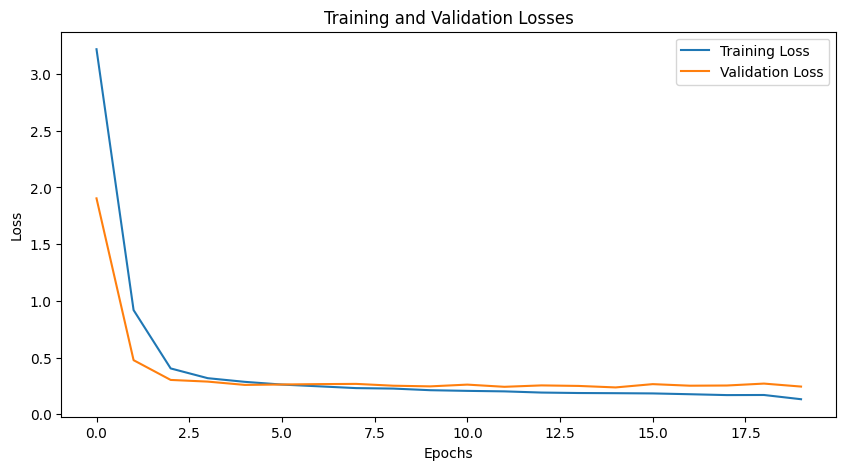

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [71]:
model.eval()  
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True) 
        labels = labels.to(device, non_blocking=True) 
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f"Test Loss: {test_loss / len(test_loader)}")

Test Accuracy: 91.94%
Test Loss: 0.26135084561154814


In [68]:
torch.save(model.state_dict(), 'VGG13_model.pth')

In [72]:
epochs = 20
test_accuracy = test_accuracy
test_loss = test_loss / len(test_loader)

test_accuracy_list = [test_accuracy] * epochs
test_loss_list = [test_loss] * epochs

print(test_accuracy_list)
print(test_loss_list)

[91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413, 91.93948412698413]
[0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814, 0.26135084561154814]


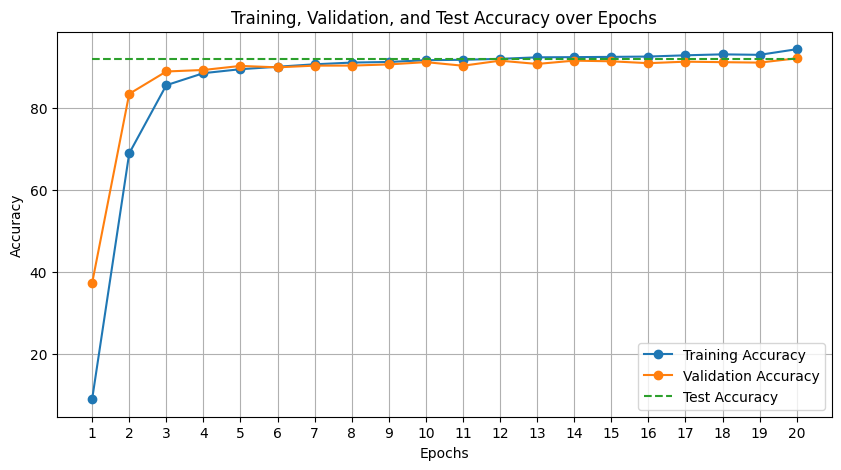

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')

plt.title('Training, Validation, and Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

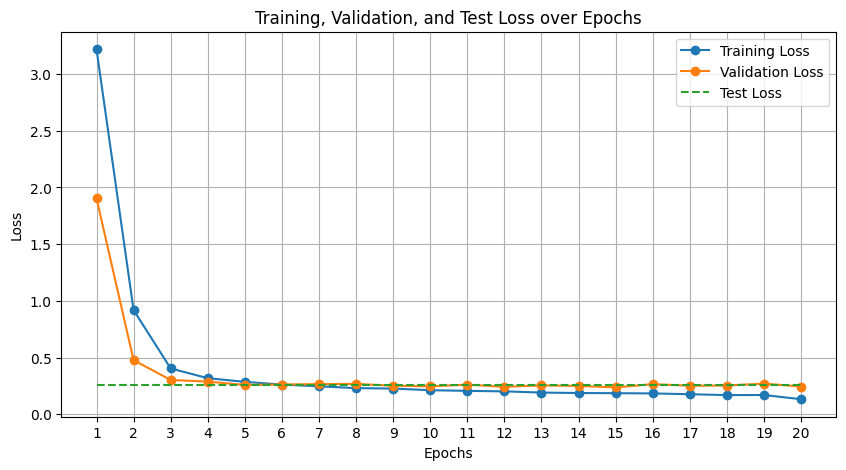

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.plot(range(1, epochs + 1), test_loss_list, label='Test Loss', linestyle='--')

plt.title('Training, Validation, and Test Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

torch.Size([20160, 36])
torch.Size([20160])


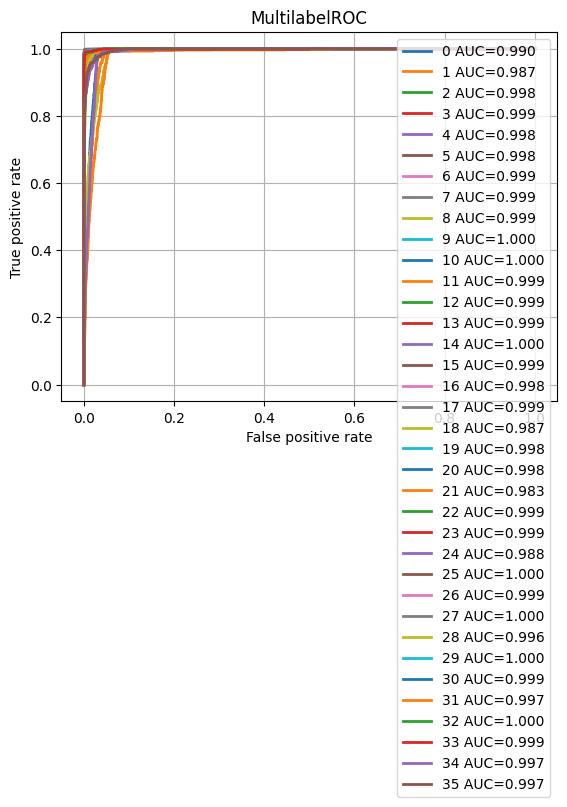

In [77]:
from sklearn.metrics import roc_auc_score
import torchmetrics
from torchmetrics.classification import MulticlassF1Score


roc = torchmetrics.classification.MultilabelROC(num_labels = 36)

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        y_true.append(labels)
        y_scores.append(outputs)

        #roc.update(predicted, labels)

y_scores = torch.cat(y_scores, dim=0)
y_true = torch.cat(y_true, dim=0)
print(y_scores.shape)
print(y_true.shape)

y_true_one_hot = torch.zeros(y_true.size(0), num_classes, device=y_true.device, dtype=torch.long)
y_true_one_hot.scatter_(1, y_true.unsqueeze(1), 1)

roc.update(y_scores, y_true_one_hot)
fig_, ax_ = roc.plot(score=True)

In [78]:
precision = torchmetrics.classification.MulticlassPrecision(num_classes=36).to(device)
recall = torchmetrics.classification.MulticlassRecall(num_classes=36).to(device)
f1 = torchmetrics.classification.MulticlassF1Score(num_classes=36).to(device)

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs, dim=1)
        y_true.append(labels)
        y_scores.append(y_pred)

        #roc.update(predicted, labels)

y_scores = torch.cat(y_scores, dim=0)
y_true = torch.cat(y_true, dim=0)
print(y_scores.shape)
print(y_true.shape)
print("\n")

precision.update(y_scores, y_true)
recall.update(y_scores, y_true)
f1.update(y_scores, y_true)

precision = precision.compute()
recall = recall.compute()
f1 = f1.compute()

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

torch.Size([20160])
torch.Size([20160])


Precision: 0.9218015670776367
Recall: 0.9193947911262512
F1 Score: 0.9188163876533508


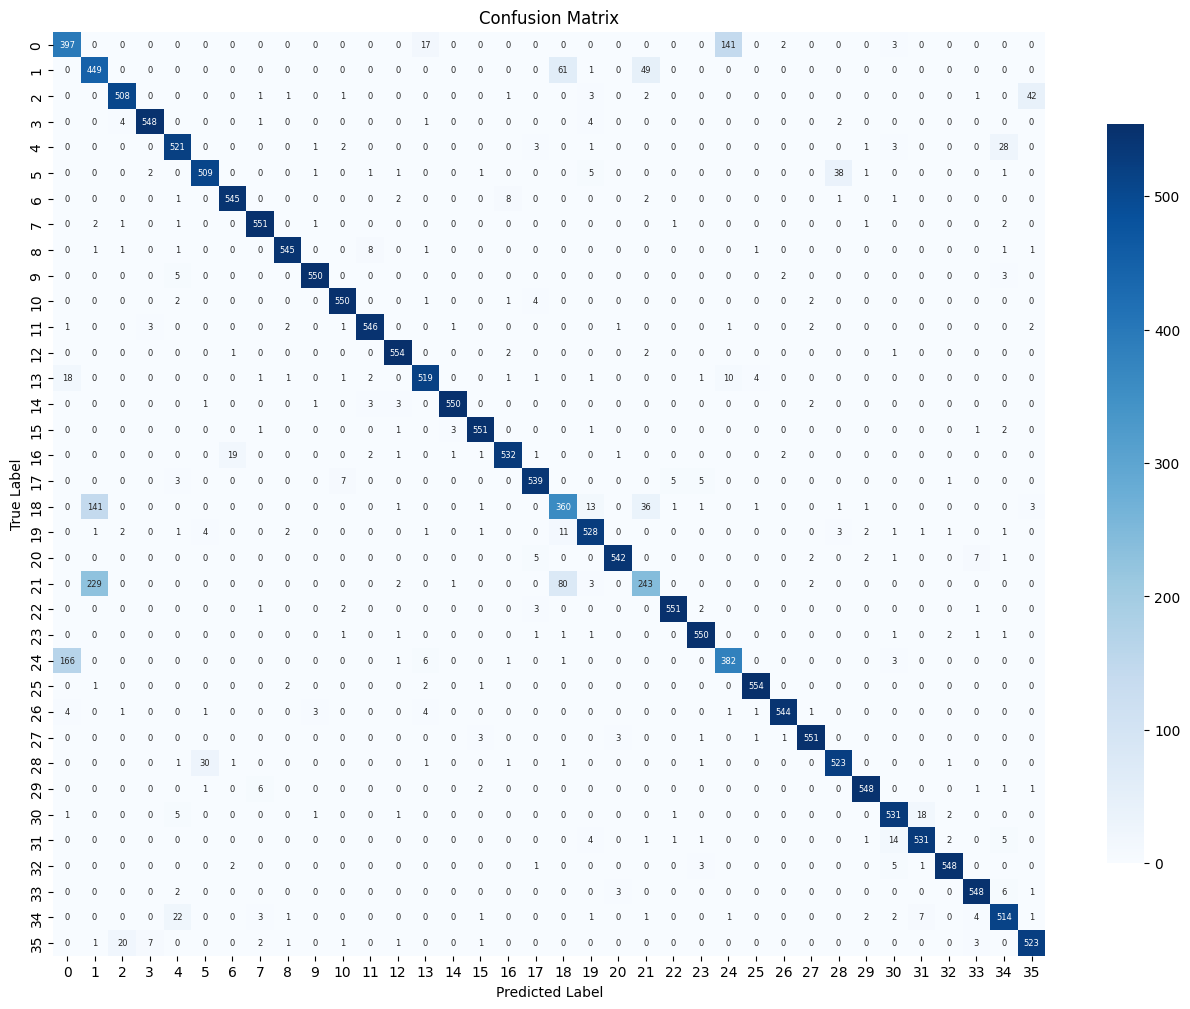

In [79]:
from sklearn.metrics import confusion_matrix

y_true_cpu = y_true.cpu().numpy() 
y_pred_cpu = y_scores.cpu().numpy()  

cm = confusion_matrix(y_true_cpu, y_pred_cpu, labels=np.arange(num_classes))
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes),
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.8})
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# References
1. https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
2. https://stackoverflow.com/questions/76376486/how-to-install-pytorch-with-cuda-support-using-conda
3. https://lightning.ai/docs/torchmetrics/stable/classification/roc.html
4. https://stackoverflow.com/questions/71998978/early-stopping-in-pytorch
5. https://arxiv.org/pdf/1409.1556
6. https://www.reddit.com/r/MachineLearning/comments/kvs1ex/d_here_are_17_ways_of_making_pytorch_training/